In [8]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize


In [9]:
current_holdings = {
    'ETH-USD': 500,
    'BTC-USD': 1500,
    'AMD': 1000,
    'URA': 1000,
    '^GSPC': 2000,
    'EWJ': 2000,
    'EUAD': 1000,
    'ICLN' : 1000
}

candidates = []

all_tickers = list(current_holdings.keys())+candidates

print(f"Downloading data for: {all_tickers}")
raw_data = yf.download(all_tickers, start="2024-01-01", end="2026-04-24", group_by='column', auto_adjust = False)

try:
    if 'Adj Close' in raw_data.columns:
        data = raw_data['Adj Close']#Adjusts for dividends/stock splits that might have diluted absolute value of the stock but not the return
    else:
        data = raw_data
    
    data = data.ffill().dropna() #Forward Fill 

    print("\nData shape:", data.shape)
    print(data.head())

except KeyError as e:
    print(f"\nStructure Error: {e}")
    print("Columns are:", raw_data.columns)

[*********************100%***********************]  8 of 8 completed


Data shape: (549, 8)
Ticker             AMD       BTC-USD      ETH-USD       EUAD        EWJ  \
Date                                                                      
2024-10-22  154.089996  67361.406250  2620.197510  25.049911  64.077560   
2024-10-23  152.910004  66432.195312  2509.098877  24.731503  62.768902   
2024-10-24  153.440002  68161.054688  2534.498535  24.842947  63.286720   
2024-10-25  156.229996  66642.414062  2435.934082  24.678766  63.305538   
2024-10-26  156.229996  67014.695312  2479.603271  24.678766  63.305538   

Ticker           ICLN        URA        ^GSPC  
Date                                           
2024-10-22  12.951798  30.433577  5851.200195  
2024-10-23  12.728157  29.337038  5797.419922  
2024-10-24  12.757328  29.522892  5809.859863  
2024-10-25  12.796222  29.327745  5808.120117  
2024-10-26  12.796222  29.327745  5808.120117  


In [10]:
#Converting prices into returns via log returns, allowing for linear sums of returns over time
log_returns = np.log(data/data.shift(1))
log_returns = log_returns.dropna()

print("Log Returns Shape", log_returns.shape)
log_returns.head()

Log Returns Shape (548, 8)


Ticker,AMD,BTC-USD,ETH-USD,EUAD,EWJ,ICLN,URA,^GSPC
Date,,,,,,,,
2024-10-23,-0.007687,-0.013890,-0.043326,-0.012792,-0.020634,-0.017418,-0.036696,-0.009234
2024-10-24,0.003460,0.025692,0.010072,0.004496,0.008216,0.002289,0.006315,0.002143
2024-10-25,0.018020,-0.022532,-0.039666,-0.006631,0.000297,0.003044,-0.006632,-0.000299
2024-10-26,0.000000,0.005571,0.017768,0.000000,0.000000,0.000000,0.000000,0.000000
2024-10-27,0.000000,0.013555,0.010566,0.000000,0.000000,0.000000,0.000000,0.000000


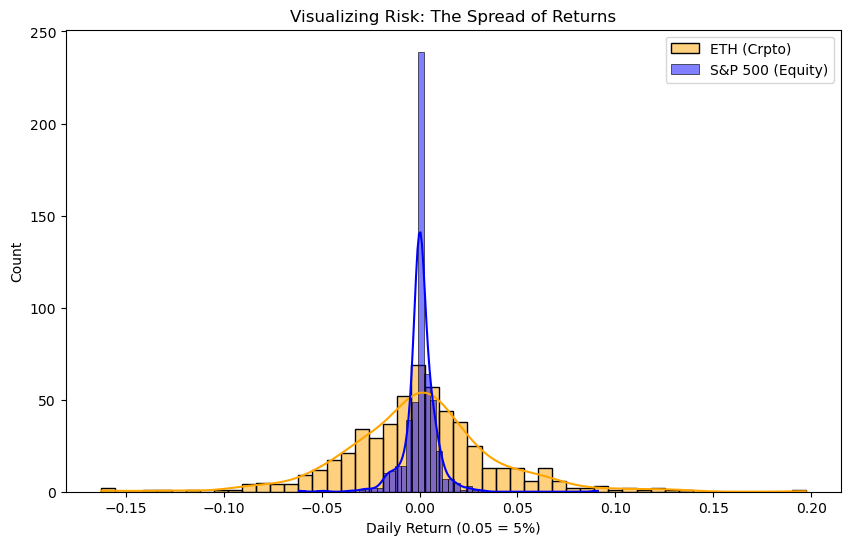

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(log_returns['ETH-USD'],bins=50,kde=True, color='orange', label='ETH (Crpto)', alpha=0.5)

sns.histplot(log_returns['^GSPC'],bins=50,kde=True, color='blue', label='S&P 500 (Equity)', alpha=0.5)

plt.title("Visualizing Risk: The Spread of Returns")
plt.xlabel("Daily Return (0.05 = 5%)")
plt.legend()
plt.show()

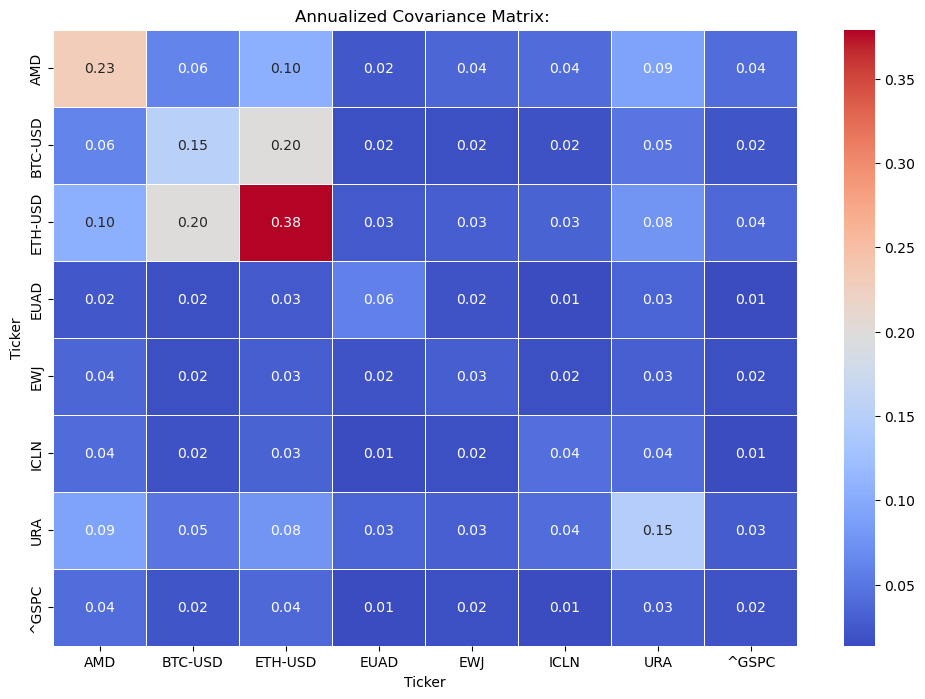


Covariance Matrix (Annualized)


Ticker,AMD,BTC-USD,ETH-USD,EUAD,EWJ,ICLN,URA,^GSPC
Ticker,,,,,,,,
AMD,0.230601,0.060993,0.104768,0.023687,0.035780,0.039642,0.091044,0.041953
BTC-USD,0.060993,0.150851,0.198076,0.017673,0.017340,0.018288,0.048749,0.021454
ETH-USD,0.104768,0.198076,0.378936,0.026348,0.028321,0.032374,0.077522,0.037002
EUAD,0.023687,0.017673,0.026348,0.059007,0.020724,0.013858,0.033878,0.013813
EWJ,0.035780,0.017340,0.028321,0.020724,0.028660,0.017363,0.030230,0.017033


In [12]:
covar_matrix= log_returns.cov() * 252

plt.figure(figsize=(12,8))
sns.heatmap(covar_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidths=.5)
plt.title("Annualized Covariance Matrix: ")
plt.show()
print("\nCovariance Matrix (Annualized)")
covar_matrix.head()

In [13]:
valid_tickers = [t for t in current_holdings.keys() if t in data.columns]
current_values = np.array([current_holdings[t]for t in valid_tickers])
current_total = np.sum(current_values)
current_weights = current_values / current_total

full_currnet_weights = np.array([current_holdings.get(ticker,0)/current_total for ticker in data.columns])

baseline_return = np.sum(log_returns.mean() * full_currnet_weights)*252

baseline_variance = np.dot(full_currnet_weights.T,np.dot(covar_matrix, full_currnet_weights))
baseline_volatility = np.sqrt(baseline_variance)

print("---SATTUS QUO (Current Portfolio)---")
print(f"Total Invested: ${current_total:.0f}")
print(f"Annual Volatility (Risk): {baseline_volatility:.2%}")
print(f"Naive Annual Return: {baseline_return:.2%}")
print(f"Sharpe Ratio: {baseline_return/baseline_volatility:.2f}")

def portfolio_volatility(weights, covar_matrix):
    return np.sqrt(np.dot(weights.T,np.dot(covar_matrix, weights)))

num_assets = len(data.columns)
initial_guess = [1/num_assets]*num_assets
bounds = tuple((0,1)for _ in range(num_assets))
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x)-1})

result = minimize(portfolio_volatility,initial_guess,args=(covar_matrix),method = 'SLSQP',bounds=bounds,constraints = constraints)

min_vol_weights = result.x
min_volatility = result.fun
min_vol_return = np.sum(log_returns.mean() * min_vol_weights) * 252

print("\n---OPTIMIZED MODEL ( Minimun Variance) ---")
print(f"Minimun Possible Volatility: {min_volatility:.2%}")
print(f"Risk Reduction: {baseline_volatility-min_volatility:.2%}")
print(f"Naive Annual Return: {min_vol_return:.2%}")
print(f"Sharpe Ratio: {min_vol_return/min_volatility:.2f}")

comparison_df = pd.DataFrame({'Asset':data.columns,'Your Current Allocation': full_currnet_weights, 'Optimized Allocation': min_vol_weights})

comparison_df = comparison_df[comparison_df['Optimized Allocation']>0.001]
comparison_df['Your Current Allocation']= comparison_df['Your Current Allocation'].apply(lambda x: f"{x:.1%}")
comparison_df['Optimized Allocation'] = comparison_df['Optimized Allocation'].apply(lambda x: f"{x:.1%}")

print("\nAlloction Comparison:")
print(comparison_df)

---SATTUS QUO (Current Portfolio)---
Total Invested: $10000
Annual Volatility (Risk): 19.69%
Naive Annual Return: 15.60%
Sharpe Ratio: 0.79

---OPTIMIZED MODEL ( Minimun Variance) ---
Minimun Possible Volatility: 13.60%
Risk Reduction: 6.09%
Naive Annual Return: 12.26%
Sharpe Ratio: 0.90

Alloction Comparison:
   Asset Your Current Allocation Optimized Allocation
3   EUAD                   10.0%                 9.0%
4    EWJ                   20.0%                 9.2%
5   ICLN                   10.0%                14.6%
7  ^GSPC                   20.0%                67.2%


Running Monte Carlo Simulation...


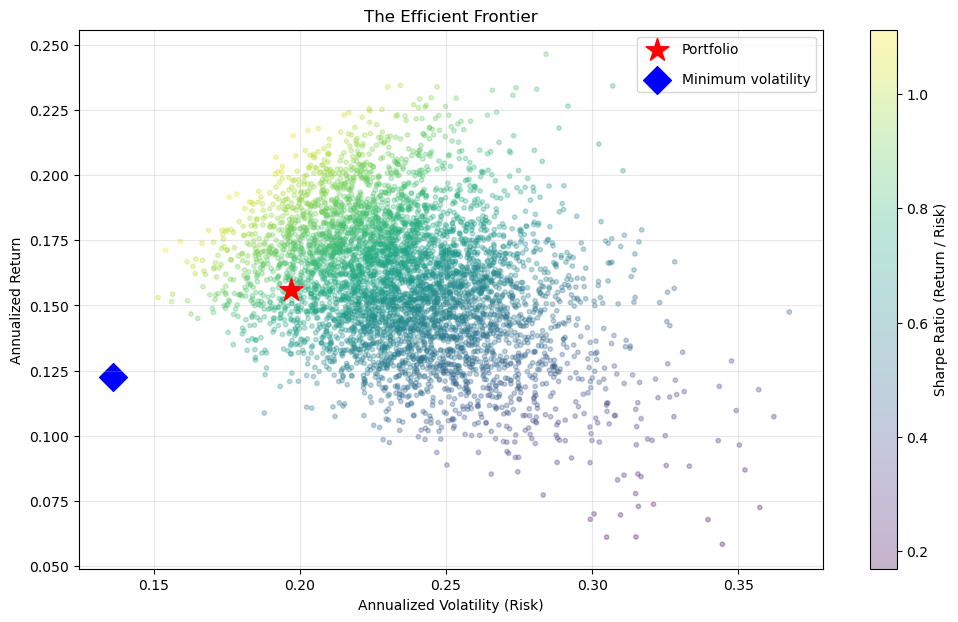

In [14]:


num_portfolios = 5000
results = np.zeros((3, num_portfolios)) 
all_weights = [] 

print("Running Monte Carlo Simulation...")

for i in range(num_portfolios):
    
    weights = np.random.random(len(all_tickers))
    weights /= np.sum(weights) 
    all_weights.append(weights)
    
    
    
    port_return = np.sum(log_returns.mean() * weights) * 252
    
    port_std = np.sqrt(np.dot(weights.T, np.dot(covar_matrix, weights)))
    
    
    results[0,i] = port_return
    results[1,i] = port_std
    results[2,i] = port_return / port_std 


plt.figure(figsize=(12, 7))


plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio (Return / Risk)')


plt.scatter(baseline_volatility, baseline_return, marker='*', color='red', s=300, label='Portfolio')


plt.scatter(min_volatility, min_vol_return, marker='D', color='blue', s=200, label='Minimum volatility')

plt.title('The Efficient Frontier')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.legend(labelspacing=1.2)
plt.grid(True, alpha=0.3)
plt.show()